In [24]:
import pandas as  pd 
import numpy as np
from sklearn import linear_model

In [25]:
df = pd.read_csv("hiring.csv")
df

,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,NaN,8.0,9,50000
1,NaN,8.0,6,45000
2,five,6.0,7,60000
3,two,10.0,10,65000
4,seven,9.0,6,70000
5,three,7.0,10,62000
6,ten,NaN,7,72000
7,eleven,7.0,8,80000


In [26]:
import math
median_ts = math.floor(df['test_score(out of 10)'].median())
median_is = math.floor(df['interview_score(out of 10)'].median())
median_ts
#median_is

8

In [27]:
# 1. Buat kamus terjemahan kata ke angka
kamus_angka = {
    'one': 1, 'two': 2, 'three': 3, 'four': 4, 'five': 5,
    'six': 6, 'seven': 7, 'eight': 8, 'nine': 9, 'ten': 10,
    'eleven': 11, 'twelve': 12, 'thirteen': 13, 'fourteen': 14, 'fifteen': 15,
    'zero': 0
}

# 2. Ubah kata menjadi angka pakai .map()
df['experience'] = df['experience'].map(kamus_angka)

# 3. Isi nilai NaN (kosong) dengan angka 0 (karena NaN di sini artinya belum punya pengalaman kerja / fresh graduate)
df['experience'] = df['experience'].fillna(0)

# 4. (Opsional) Ubah tipe datanya menjadi integer (bilangan bulat murni)
df['experience'] = df['experience'].astype(int)

# Cek hasilnya
df

,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,0,8.0,9,50000
1,0,8.0,6,45000
2,5,6.0,7,60000
3,2,10.0,10,65000
4,7,9.0,6,70000
5,3,7.0,10,62000
6,10,NaN,7,72000
7,11,7.0,8,80000


In [28]:
df['test_score(out of 10)'] = df['test_score(out of 10)'].fillna(median_ts)
df

,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,0,8.0,9,50000
1,0,8.0,6,45000
2,5,6.0,7,60000
3,2,10.0,10,65000
4,7,9.0,6,70000
5,3,7.0,10,62000
6,10,8.0,7,72000
7,11,7.0,8,80000


In [29]:
reg = linear_model.LinearRegression()
reg.fit(df[['experience', 'test_score(out of 10)', 'interview_score(out of 10)']], df['salary($)'])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [30]:
reg.coef_

array([2812.95487627, 1845.70596798, 2205.24017467])

In [31]:
reg.intercept_

np.float64(17737.263464337688)

In [32]:
reg.predict([[1, 6.0, 9]])

/home/lenovo/anaconda3/envs/ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([51471.61572052])

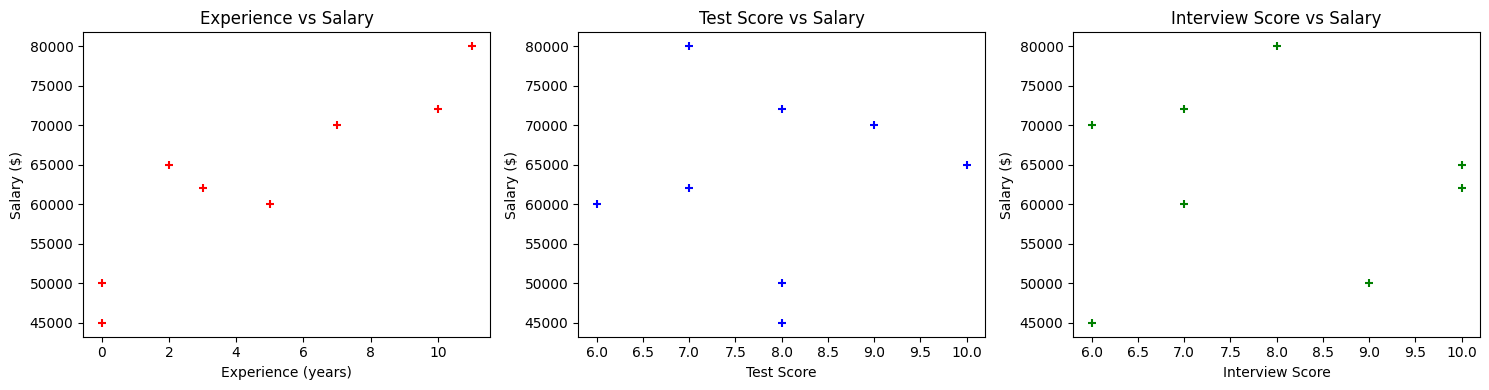

In [35]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 4))

# 1. Experience vs Salary
plt.subplot(1, 3, 1)
plt.scatter(df['experience'], df['salary($)'], color='red', marker='+')
plt.title('Experience vs Salary')
plt.xlabel('Experience (years)')
plt.ylabel('Salary ($)')

# 2. Test Score vs Salary
plt.subplot(1, 3, 2)
plt.scatter(df['test_score(out of 10)'], df['salary($)'], color='blue', marker='+')
plt.title('Test Score vs Salary')
plt.xlabel('Test Score')
plt.ylabel('Salary ($)')

# 3. Interview Score vs Salary
plt.subplot(1, 3, 3)
plt.scatter(df['interview_score(out of 10)'], df['salary($)'], color='green', marker='+')
plt.title('Interview Score vs Salary')
plt.xlabel('Interview Score')
plt.ylabel('Salary ($)')

plt.tight_layout()
plt.show()